In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
!pip install snowflake-connector-python

In [46]:

import snowflake.connector
conn=snowflake.connector.connect(
    user='Gopi',
    password='Gopisubramani2006',
    account='EKTTFHN-OI95948',
    database='GOPIDB1',
    schema='PUBLIC',
    warehouse='COMPUTE_WH'
)

In [47]:
querry='SELECT*FROM GOPI'
df=pd.read_sql(querry,conn)
conn.close()

/tmp/ipykernel_3447/3441347201.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df=pd.read_sql(querry,conn)


In [48]:
df.head()

,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC_DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL_CONSUMING,COUGHING,SHORTNESS_OF_BREATH,SWALLOWING_DIFFICULTY,CHEST_PAIN,LUNG_CANCER
0,M,69,1,2,2,1,1,2,1,2,2,2,2,2,2,True
1,M,74,2,1,1,1,2,2,2,1,1,1,2,2,2,True
2,F,59,1,1,1,2,1,2,1,2,1,2,2,1,2,False
3,M,63,2,2,2,1,1,1,1,1,2,1,1,2,2,False
4,F,63,1,2,1,1,1,1,1,2,1,2,2,1,1,False


In [49]:
df.tail()

,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC_DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL_CONSUMING,COUGHING,SHORTNESS_OF_BREATH,SWALLOWING_DIFFICULTY,CHEST_PAIN,LUNG_CANCER
304,F,56,1,1,1,2,2,2,1,1,2,2,2,2,1,True
305,M,70,2,1,1,1,1,2,2,2,2,2,2,1,2,True
306,M,58,2,1,1,1,1,1,2,2,2,2,1,1,2,True
307,M,67,2,1,2,1,1,2,2,1,2,2,2,1,2,True
308,M,62,1,1,1,2,1,2,2,2,2,1,1,2,1,True


In [50]:
df.shape

(309, 16)

In [51]:
df.describe()

,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC_DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL_CONSUMING,COUGHING,SHORTNESS_OF_BREATH,SWALLOWING_DIFFICULTY,CHEST_PAIN
count,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000
mean,62.673139,1.563107,1.569579,1.498382,1.501618,1.504854,1.673139,1.556634,1.556634,1.556634,1.579288,1.640777,1.469256,1.556634
std,8.210301,0.496806,0.495938,0.500808,0.500808,0.500787,0.469827,0.497588,0.497588,0.497588,0.494474,0.480551,0.499863,0.497588
min,21.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,57.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
50%,62.000000,2.000000,2.000000,1.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,1.000000,2.000000
75%,69.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000
max,87.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000


In [52]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 309 entries, 0 to 308
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   GENDER                 309 non-null    object
 1   AGE                    309 non-null    int64 
 2   SMOKING                309 non-null    int64 
 3   YELLOW_FINGERS         309 non-null    int64 
 4   ANXIETY                309 non-null    int64 
 5   PEER_PRESSURE          309 non-null    int64 
 6   CHRONIC_DISEASE        309 non-null    int64 
 7   FATIGUE                309 non-null    int64 
 8   ALLERGY                309 non-null    int64 
 9   WHEEZING               309 non-null    int64 
 10  ALCOHOL_CONSUMING      309 non-null    int64 
 11  COUGHING               309 non-null    int64 
 12  SHORTNESS_OF_BREATH    309 non-null    int64 
 13  SWALLOWING_DIFFICULTY  309 non-null    int64 
 14  CHEST_PAIN             309 non-null    int64 
 15  LUNG_CANCER            

In [53]:
df.isnull().sum()

,0
GENDER,0
AGE,0
SMOKING,0
YELLOW_FINGERS,0
ANXIETY,0
PEER_PRESSURE,0
CHRONIC_DISEASE,0
FATIGUE,0
ALLERGY,0
WHEEZING,0


In [54]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df['GENDER']=le.fit_transform(df[['GENDER']])
df['LUNG_CANCER']=le.fit_transform(df[['LUNG_CANCER']])

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


<Axes: ylabel='AGE'>

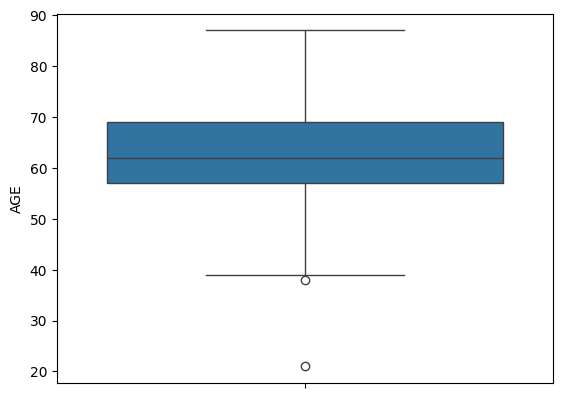

In [55]:
sns.boxplot(df['AGE'])

<Axes: ylabel='SMOKING'>

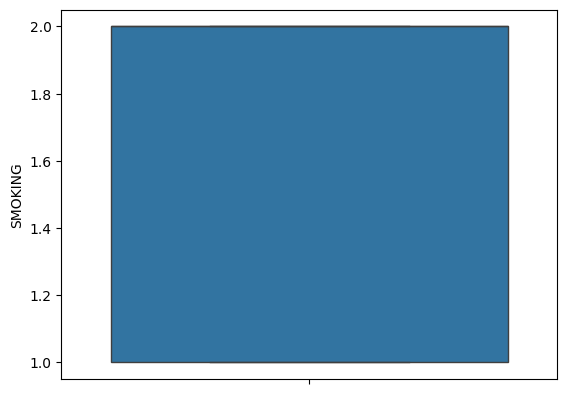

In [56]:
sns.boxplot(df['SMOKING'])

<Axes: ylabel='YELLOW_FINGERS'>

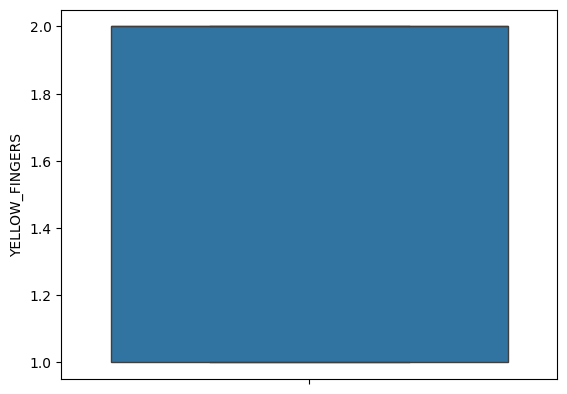

In [57]:
sns.boxplot(df['YELLOW_FINGERS'])

<Axes: ylabel='ANXIETY'>

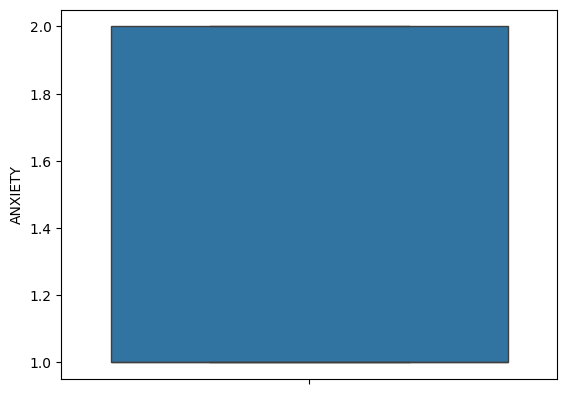

In [58]:
sns.boxplot(df['ANXIETY'])

<Axes: ylabel='PEER_PRESSURE'>

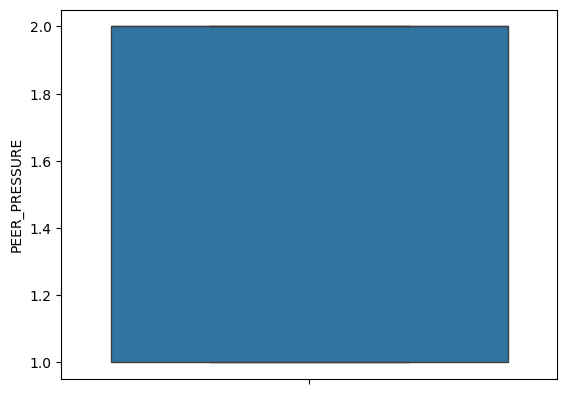

In [59]:
sns.boxplot(df['PEER_PRESSURE'])

<Axes: ylabel='CHRONIC_DISEASE'>

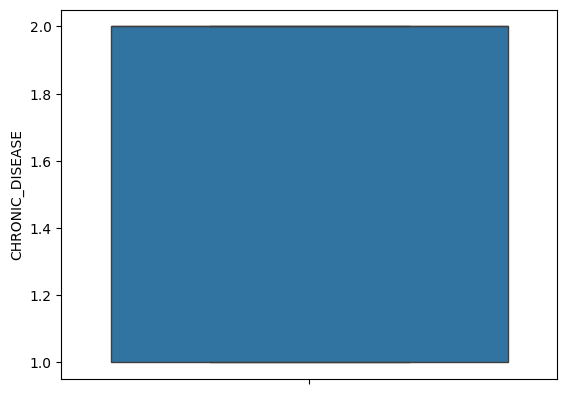

In [60]:
sns.boxplot(df['CHRONIC_DISEASE'])

<Axes: ylabel='FATIGUE'>

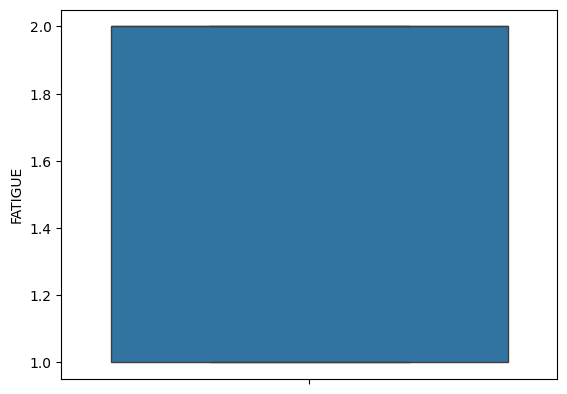

In [61]:
sns.boxplot(df['FATIGUE'])

<Axes: ylabel='ALLERGY'>

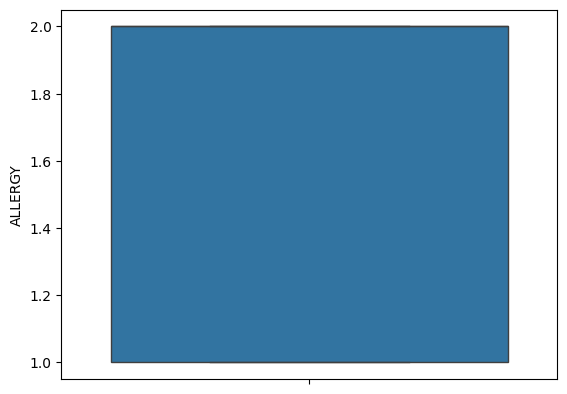

In [62]:
sns.boxplot(df['ALLERGY'])

<Axes: ylabel='WHEEZING'>

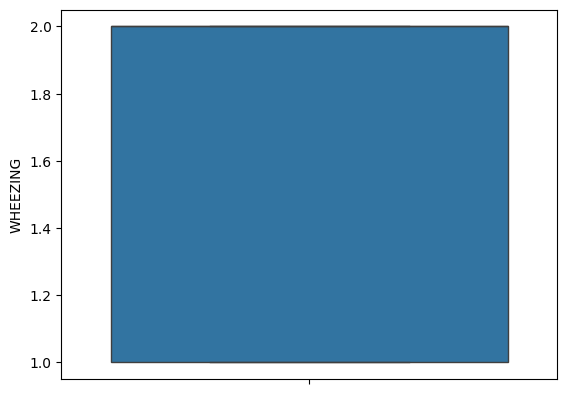

In [63]:
sns.boxplot(df['WHEEZING'])

In [64]:
from scipy.stats.mstats import winsorize
df['AGE']=winsorize(df['AGE'],limits=[0.05,0.25])


<Axes: ylabel='AGE'>

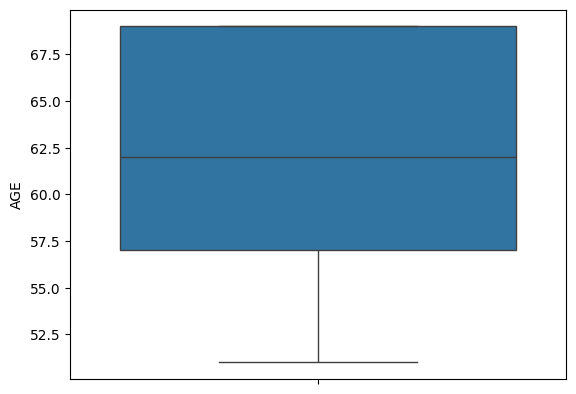

In [65]:
sns.boxplot(df['AGE'])

In [66]:
X=df[['GENDER','AGE','SMOKING','YELLOW_FINGERS','ANXIETY','PEER_PRESSURE','CHRONIC_DISEASE','FATIGUE','ALLERGY','WHEEZING','ALCOHOL_CONSUMING','COUGHING','SHORTNESS_OF_BREATH','SWALLOWING_DIFFICULTY','CHEST_PAIN']]
y=df['LUNG_CANCER'].values

In [67]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

In [68]:
from sklearn.tree import DecisionTreeClassifier
model=DecisionTreeClassifier(max_depth=3,random_state=40)
model.fit(X_train, y_train)



DecisionTreeClassifier(max_depth=3, random_state=40)

In [69]:
y_pred = model.predict(X_test)

In [70]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)

from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

[[ 3  5]
 [ 5 49]]
              precision    recall  f1-score   support

           0       0.38      0.38      0.38         8
           1       0.91      0.91      0.91        54

    accuracy                           0.84        62
   macro avg       0.64      0.64      0.64        62
weighted avg       0.84      0.84      0.84        62



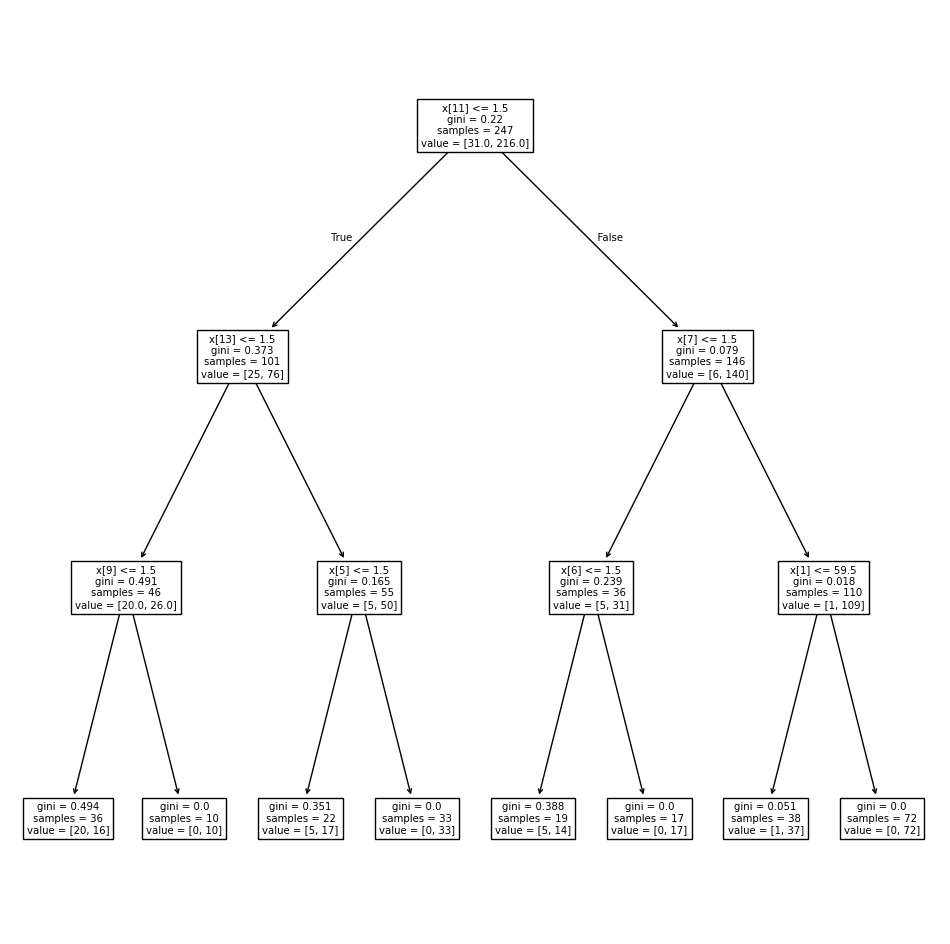

In [71]:

from sklearn import tree
fig=plt.figure(figsize=(12,12))
tree.plot_tree(model)
plt.show()

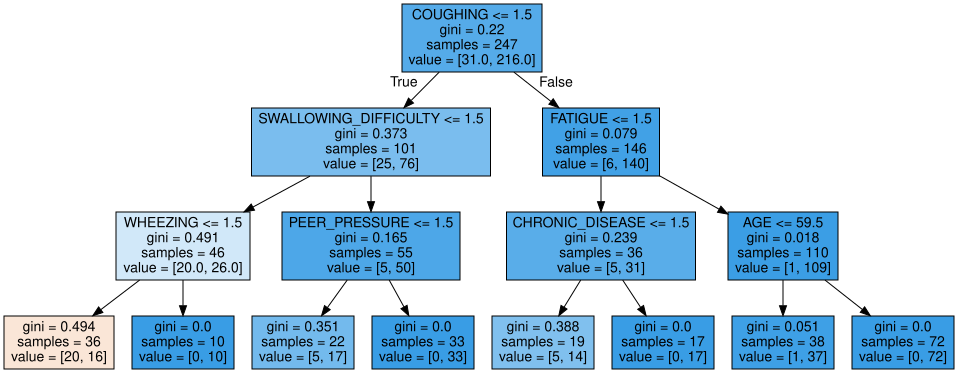

In [72]:
import graphviz
from sklearn.tree import export_graphviz
graphviz.Source(export_graphviz(model,feature_names=X.columns,filled=True))

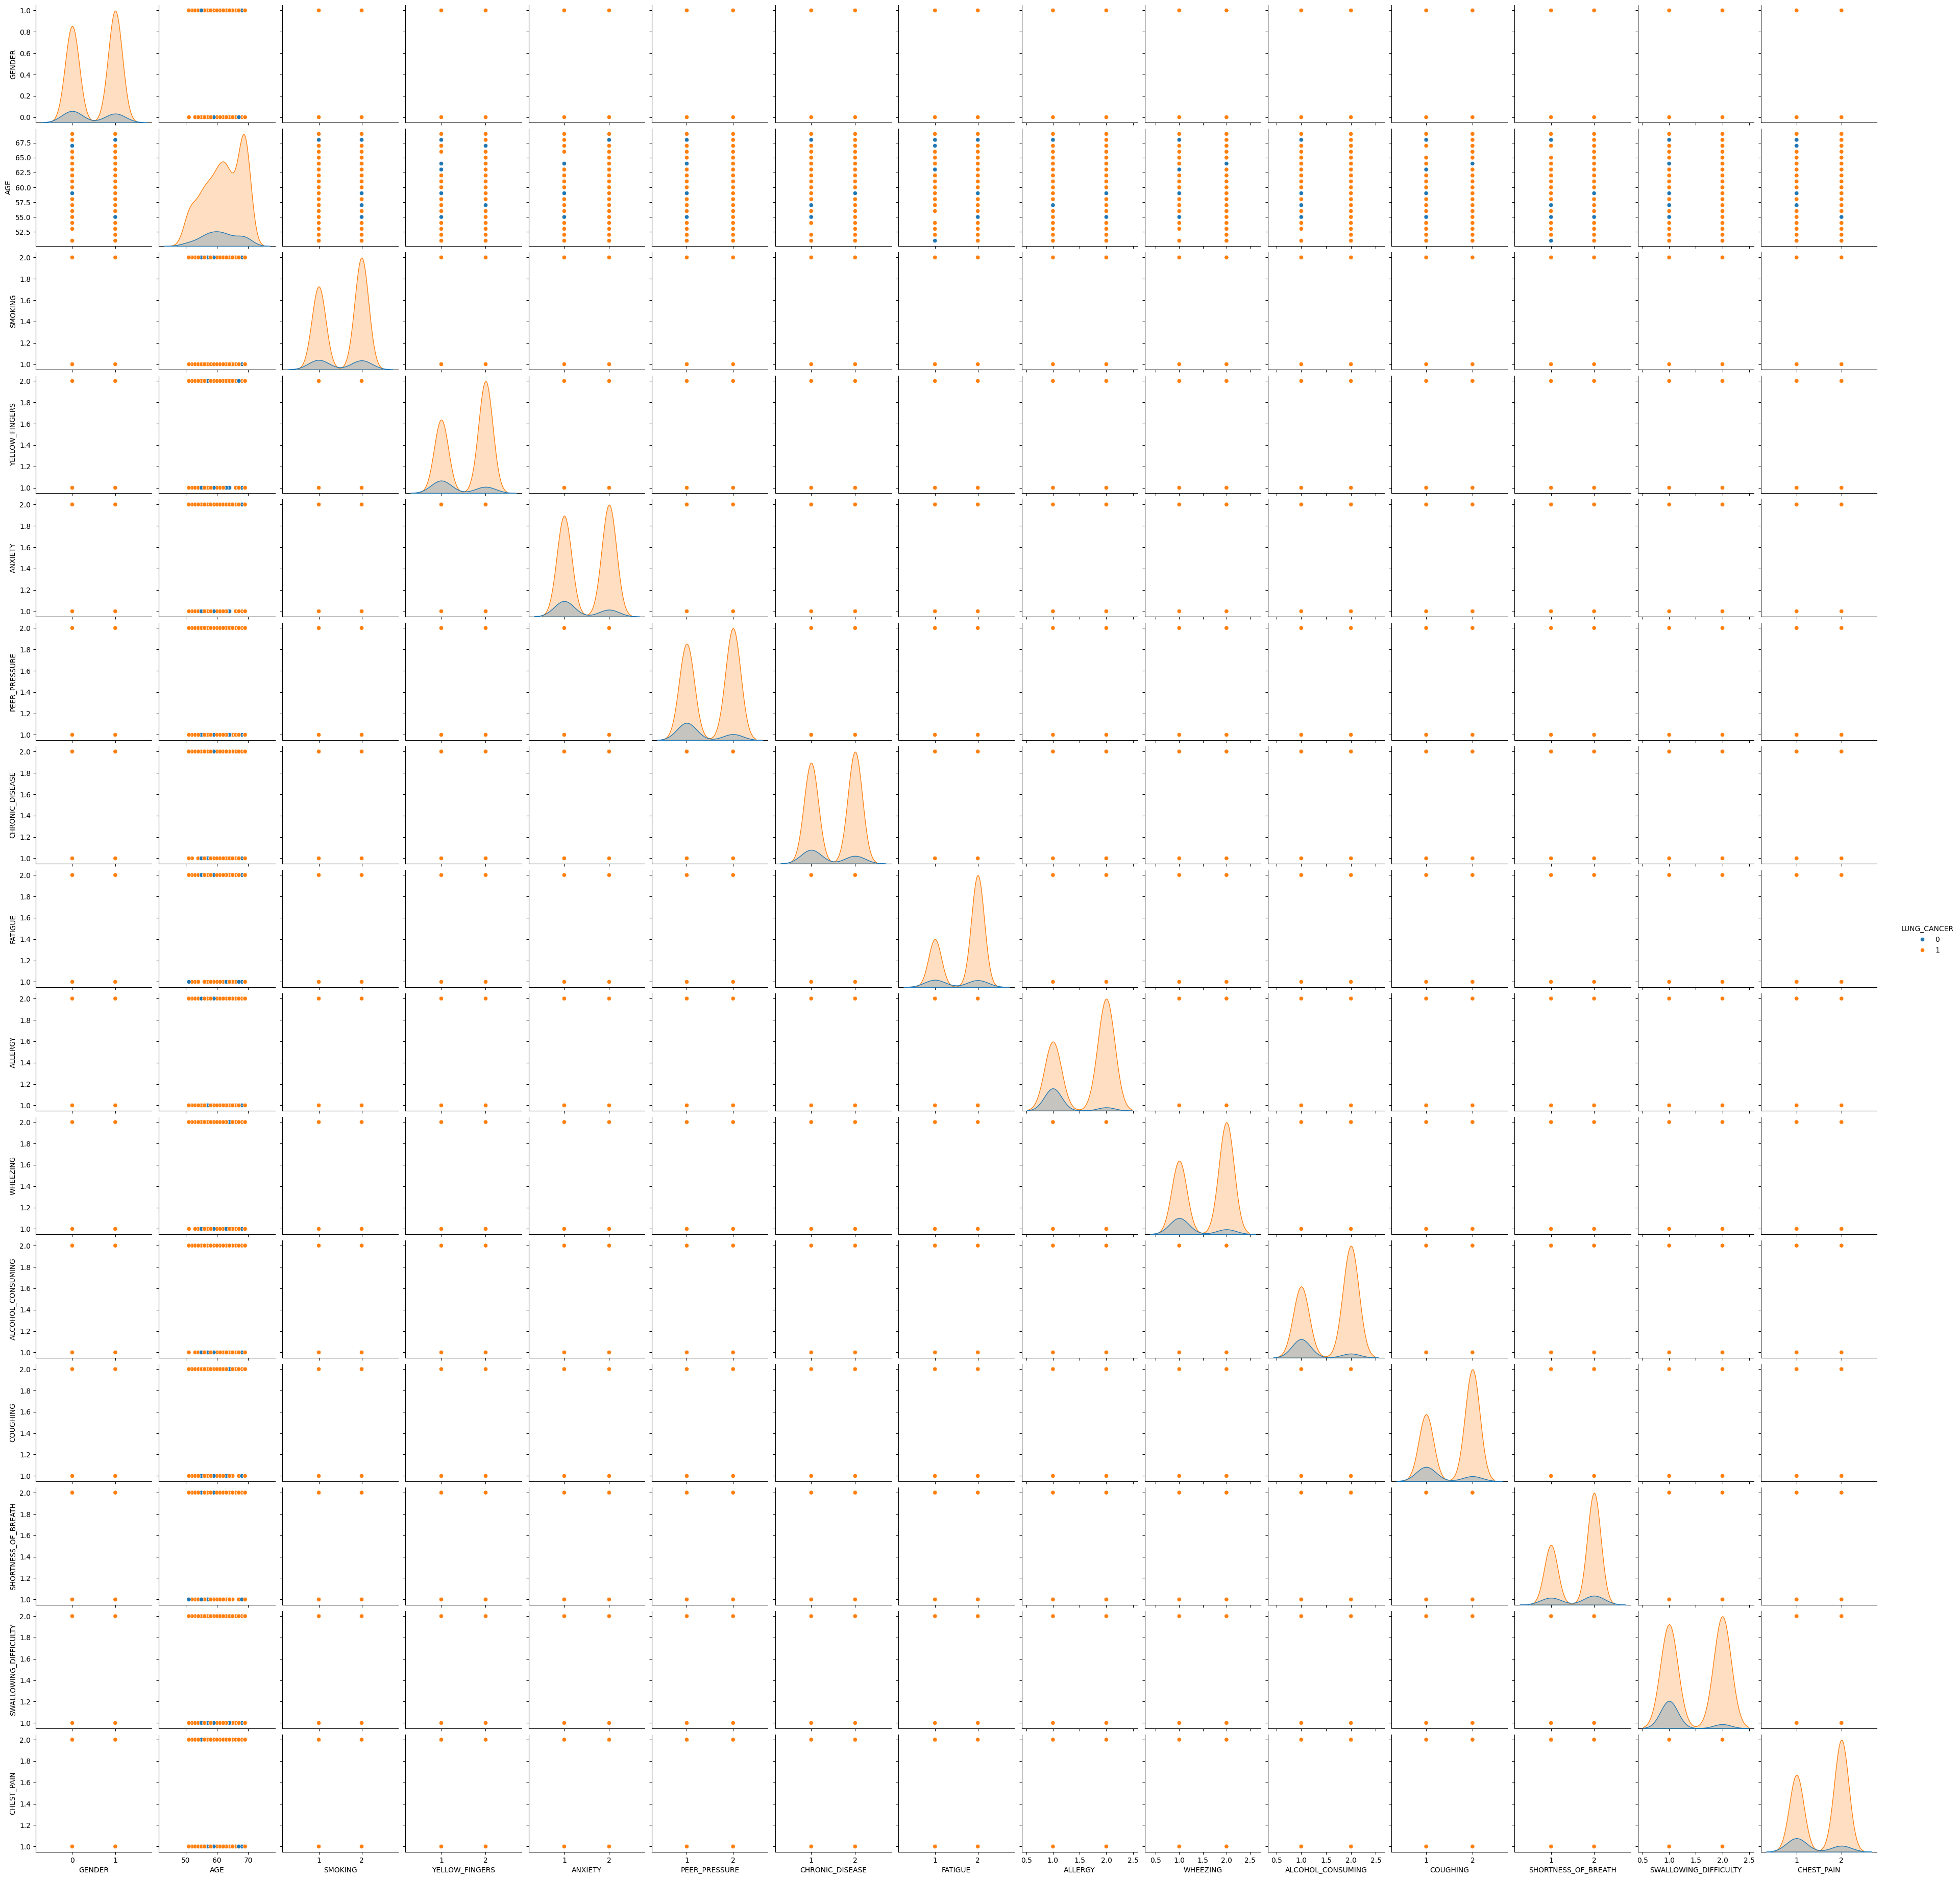

In [44]:
sns.pairplot(df,hue='LUNG_CANCER')

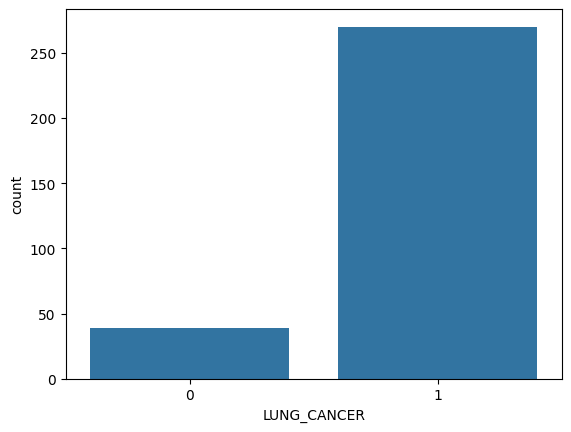

In [73]:

import seaborn as sns
import matplotlib.pyplot as plt
sns.countplot(x=df['LUNG_CANCER'])
plt.show()

In [74]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
accuracy_percent = accuracy * 100
print(f"Accuracy: {accuracy_percent:.2f}%")

Accuracy: 83.87%
